In [41]:
from pathlib import Path
from collections.abc import Hashable
from typing import Generator
from anndata import AnnData
from itertools import product

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
from numpy.typing import NDArray
from pandas import DataFrame
from scipy.stats import spearmanr

from utils import mean_randomized_cross_feature_prediction
from nmf_utils import nmf_predictor

In [3]:
def _adata_sp() -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    #adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype].copy()
    return adata_sp



def _adata_sc() -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    #adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype].copy()
    adata_sc.X = adata_sc.X.toarray()
    return adata_sc

adata_sp: AnnData = _adata_sp()
adata_sc: AnnData = _adata_sc()

assert isinstance(adata_sp.X, np.ndarray)
assert isinstance(adata_sc.X, np.ndarray)

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.intersect1d(adata_sp.var_names, adata_sc.var_names)

print(f"{adata_sp=}\n{adata_sc=}")
print(f"{len(shared_genes)=}")

adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'
adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
len(shared_genes)=203


In [26]:
methods = {
    "nmf1": lambda query_matrix, reference_matrix: nmf_predictor(query_matrix, reference_matrix, n_components=3, max_iter=1000),
    "nmf2": lambda query_matrix, reference_matrix: nmf_predictor(query_matrix, reference_matrix, n_components=3, max_iter=1000),
}

In [42]:
results = []

for (method_name, method), (celltype, query, reference) in product(methods.items(), group_by_common_obs(adata_sp, adata_sc, "celltype")):
    query_matrix = query[:, shared_genes].X
    reference_matrix = reference[:, shared_genes].X
    assert all(isinstance(m, np.ndarray) for m in (query_matrix, reference_matrix))
    
    reconstructed_counts = mean_randomized_cross_feature_prediction(
        query_matrix,
        reference_matrix,
        method,
        2,
        seed=5
    )
    
    score = float(spearmanr(query_matrix.mean(axis=0), reconstructed_counts.mean(axis=0))[0])
    results.append(((method_name, celltype), (query_matrix, reconstructed_counts)))

df = pd.DataFrame(results, columns=["index", "score"])
df.set_index("index", inplace=True)
df.index = pd.MultiIndex.from_tuples(df.index, names=["method", "celltype"])

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-

In [53]:
df["score"][("nmf1", "BZE")]

(ArrayView([[0., 0., 0., ..., 1., 0., 0.],
            [0., 0., 0., ..., 0., 0., 2.],
            [0., 0., 0., ..., 5., 0., 0.],
            ...,
            [1., 0., 0., ..., 0., 0., 0.],
            [1., 0., 0., ..., 0., 0., 0.],
            [0., 0., 0., ..., 1., 0., 1.]], dtype=float32),
 array([[1.5862843e-01, 2.0845153e-03, 1.7731428e-02, ..., 4.4569638e-02,
         3.1567113e-03, 1.9461475e-03],
        [2.2223328e-01, 4.6693720e-03, 2.9346935e-02, ..., 5.7061091e-02,
         5.0058467e-03, 4.3010209e-03],
        [5.3393734e-01, 9.6421884e-03, 5.1677518e-02, ..., 1.0805474e-01,
         7.1728784e-03, 9.2315758e-03],
        ...,
        [3.4521900e-02, 2.1028761e-03, 1.6243145e-04, ..., 2.3459544e-02,
         4.8157439e-04, 1.9704546e-03],
        [7.7137306e-02, 1.5585904e-03, 8.0091525e-03, ..., 6.1420500e-02,
         2.8554490e-03, 1.6815923e-03],
        [5.0744358e-02, 9.3371904e-04, 1.5747531e-03, ..., 2.5577407e-02,
         4.5300677e-04, 7.8833126e-04]], dtype=floa

In [56]:
df["score"].apply(lambda t: float(spearmanr(t[0].mean(axis=0), t[1].mean(axis=0))[0]))

method  celltype               
nmf1    BZE                        0.633853
        Blood vasc.                0.671552
        Cycling/GC B cell          0.416870
        Glial                      0.488644
        Goblet                     0.684159
        Lymphatic                  0.562382
        MZE                        0.653648
        Macrophage                 0.722639
        Paneth                     0.716413
        Plasma                     0.616911
        Rest B                     0.615064
        Stem/TA                    0.726464
        Stroma                     0.664660
        T cell                     0.706101
        TZE                        0.572658
        Tuft                       0.635123
        cDC/monocyte               0.654253
        neurons/enteroendocrine    0.678122
        pDC                        0.543178
nmf2    BZE                        0.633853
        Blood vasc.                0.671552
        Cycling/GC B cell          0.416870


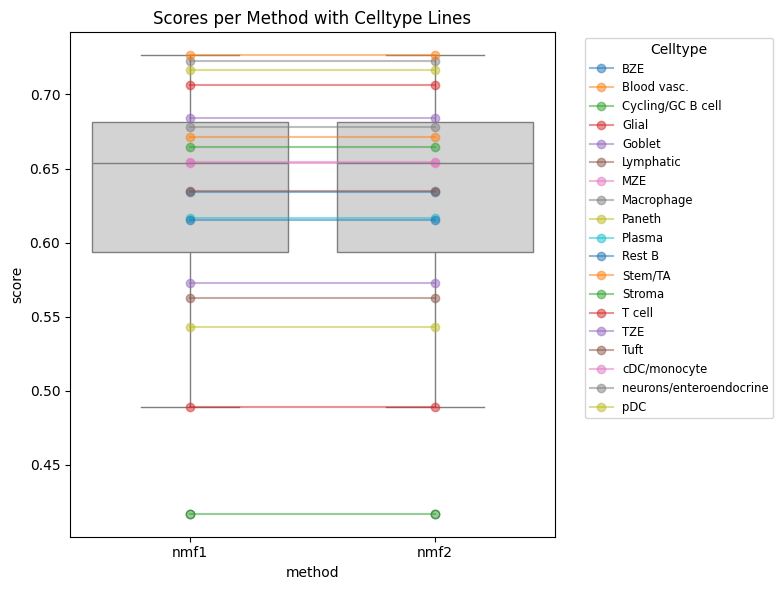

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_reset = df.reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")

for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.tight_layout()
plt.show()

In [32]:
df.reset_index()

,method,celltype,score
0,nmf1,BZE,0.633853
1,nmf1,Blood vasc.,0.671552
2,nmf1,Cycling/GC B cell,0.416870
3,nmf1,Glial,0.488644
4,nmf1,Goblet,0.684159
5,nmf1,Lymphatic,0.562382
6,nmf1,MZE,0.653648
7,nmf1,Macrophage,0.722639
8,nmf1,Paneth,0.716413
9,nmf1,Plasma,0.616911


In [10]:
from numpy import ndarray

nmf_res = {}
for celltype, query, reference in group_by_common_obs(adata_sp, adata_sc, "celltype"):
    query_matrix = query[:, shared_genes].X
    reference_matrix = reference[:, shared_genes].X
    assert all(isinstance(m, np.ndarray) for m in (query_matrix, reference_matrix))
    reconstructed_counts = mean_randomized_cross_feature_prediction(
        query_matrix,
        reference_matrix,
        lambda query_matrix, reference_matrix: nmf_predictor(query_matrix, reference_matrix, n_components=3, max_iter=1000),
        2,
        seed=5
    )
    nmf_res[celltype] = float(spearmanr(query_matrix.mean(axis=0), reconstructed_counts.mean(axis=0))[0])

nmf_res2 = nmf_res.copy()

/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/scvi_mps-

In [18]:
df = DataFrame({
    "nmf_res": nmf_res,
    "nmf_res2": nmf_res2,
})

In [13]:
df

,nmf_res,nmf_res2
BZE,0.633853,0.633853
Blood vasc.,0.671552,0.671552
Cycling/GC B cell,0.416870,0.416870
Glial,0.488644,0.488644
Goblet,0.684159,0.684159
Lymphatic,0.562382,0.562382
MZE,0.653648,0.653648
Macrophage,0.722639,0.722639
Paneth,0.716413,0.716413
Plasma,0.616911,0.616911


In [20]:
df_long

,celltype,source,score
0,BZE,nmf_res,0.633853
1,Blood vasc.,nmf_res,0.671552
2,Cycling/GC B cell,nmf_res,0.416870
3,Glial,nmf_res,0.488644
4,Goblet,nmf_res,0.684159
5,Lymphatic,nmf_res,0.562382
6,MZE,nmf_res,0.653648
7,Macrophage,nmf_res,0.722639
8,Paneth,nmf_res,0.716413
9,Plasma,nmf_res,0.616911
